# 04 -- Segmentacion RFM, Estimacion de LTV y Analisis de Activacion

**Pregunta de negocio:** *Como segmentamos clientes por valor, estimamos LTV, e identificamos que comportamientos en la primera compra predicen engagement a largo plazo?*

**Contexto:** Solo ~3% de los clientes de Olist son compradores recurrentes. Este notebook cuantifica la concentracion de valor, segmenta clientes por comportamiento (RFM), estima curvas de LTV por segmento, y usa regresion logistica para identificar los factores de la primera compra que predicen la recompra.

---

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path('../../../scripts/utils')))
from theme import apply_plotly_theme, apply_seaborn_theme, COLORS, SEQUENTIAL, CATEGORICAL

apply_seaborn_theme()
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Dependencias cargadas correctamente.')

Dependencias cargadas correctamente.


In [2]:
DATA_DIR = Path('../data/processed')
OUT_DIR = Path('../data/processed')

orders = pd.read_parquet(DATA_DIR / 'orders_enriched.parquet')
customers = pd.read_parquet(DATA_DIR / 'customers_summary.parquet')
items = pd.read_parquet(DATA_DIR / 'items_enriched.parquet')

REFERENCE_DATE = orders['order_purchase_timestamp'].max()

print(f'Orders: {orders.shape[0]:,} filas')
print(f'Customers: {customers.shape[0]:,} clientes unicos')
print(f'Items: {items.shape[0]:,} filas')
print(f'Fecha de referencia: {REFERENCE_DATE.date()}')
print(f'Tasa de recompra global: {customers["is_repeat_customer"].mean():.1%}')

Orders: 96,478 filas
Customers: 93,358 clientes unicos
Items: 112,650 filas
Fecha de referencia: 2018-08-29
Tasa de recompra global: 3.0%


---
## 1. Segmentacion RFM

La segmentacion RFM clasifica clientes en tres dimensiones:
- **Recency (R):** Dias desde la ultima compra (menor = mejor = mayor score)
- **Frequency (F):** Numero total de pedidos
- **Monetary (M):** Ingreso total generado

Asignamos quintiles (1-5) a cada dimension y mapeamos combinaciones de scores a segmentos accionables de negocio.

In [3]:
# --- RFM Scoring ---
rfm = customers[['customer_unique_id', 'recency_days', 'total_orders', 'total_revenue']].copy()

# Score quintiles (1-5)
# Recency: INVERSE -- lower recency = better = higher score
rfm['R'] = pd.qcut(rfm['recency_days'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
# Frequency: higher = better
# Most customers have 1 order, so qcut fails. Use rank-based scoring.
rfm['F'] = rfm['total_orders'].clip(upper=5)
rfm.loc[rfm['total_orders'] == 1, 'F'] = 1
rfm.loc[rfm['total_orders'] == 2, 'F'] = 3
rfm.loc[rfm['total_orders'] >= 3, 'F'] = 5
# Monetary: higher = better
rfm['M'] = pd.qcut(rfm['total_revenue'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# --- Segment mapping ---
def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal'
    elif r >= 3 and f <= 2 and m >= 1:
        return 'Potential Loyalist'
    elif r >= 4 and f <= 2 and m <= 2:
        return 'New'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r == 1:
        return 'Lost'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Other'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

print('Distribucion de segmentos RFM:')
print(rfm['segment'].value_counts().to_string())
print(f'\nTotal clientes segmentados: {len(rfm):,}')

Distribucion de segmentos RFM:
segment
Potential Loyalist    54329
Lost                  18250
Other                 10652
Hibernating            7509
Loyal                  1595
At Risk                 906
Champions               117

Total clientes segmentados: 93,358


**Nota sobre el scoring de Frecuencia (F):**

El score de Frecuencia utiliza una escala de 3 niveles (1/3/5) en lugar de quintiles estandar (1-5). Esta es una decision de diseno deliberada, no un error:

- **Por que fallan los quintiles:** ~97% de los clientes tienen frecuencia = 1 (una sola compra). `pd.qcut` con `q=5` no puede crear 5 bins con fronteras distintas cuando practicamente todos los valores son identicos. Forzar quintiles asignaria scores arbitrarios dentro del mismo grupo de frecuencia.
- **Por que 3 niveles (1/3/5):** Se eligio un esquema que crea separacion significativa entre los grupos reales del negocio: compradores unicos (F=1), compradores con 2 ordenes (F=3), y compradores con 3+ ordenes (F=5). Los valores 1, 3 y 5 se usan en lugar de 1, 2 y 3 para mantener la escala compatible con R y M (ambos en rango 1-5), de modo que el score RFM compuesto tenga un rango consistente.
- **Los valores 2 y 4 quedan sin usar:** Esto es intencional. No existen sub-segmentos naturales dentro de "1 orden" o "2 ordenes" que justifiquen granularidad adicional.

In [4]:
# --- Bar chart: segment sizes ---
seg_counts = rfm['segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']
seg_counts['pct'] = seg_counts['count'] / seg_counts['count'].sum() * 100
seg_counts = seg_counts.sort_values('count', ascending=True)

segment_colors = {
    'Champions': COLORS['success'],
    'Loyal': CATEGORICAL[1],
    'Potential Loyalist': COLORS['primary'],
    'New': CATEGORICAL[5],
    'At Risk': COLORS['warning'],
    'Hibernating': COLORS['neutral'],
    'Lost': COLORS['danger'],
    'Other': '#94A3B8',
}

fig = go.Figure()
fig.add_trace(go.Bar(
    y=seg_counts['segment'],
    x=seg_counts['count'],
    orientation='h',
    marker_color=[segment_colors.get(s, COLORS['neutral']) for s in seg_counts['segment']],
    text=[f'{c:,} ({p:.1f}%)' for c, p in zip(seg_counts['count'], seg_counts['pct'])],
    textposition='outside',
))
fig.update_layout(
    title='Distribucion de Segmentos RFM',
    xaxis_title='Numero de clientes',
    yaxis_title='',
    height=450,
    showlegend=False,
)
apply_plotly_theme(fig)
fig.show()

In [5]:
# --- Scatter: Recency vs Frequency, size=Monetary, color=Segment ---
# Sample for visibility (full dataset is 93K points)
rfm_plot = rfm.copy()
rfm_plot['monetary_scaled'] = np.clip(rfm_plot['total_revenue'], 0, rfm_plot['total_revenue'].quantile(0.99))

fig = px.scatter(
    rfm_plot,
    x='recency_days',
    y='total_orders',
    size='monetary_scaled',
    color='segment',
    color_discrete_map=segment_colors,
    hover_data=['total_revenue'],
    title='Mapa RFM: Recencia vs Frecuencia (tamano = valor monetario)',
    labels={
        'recency_days': 'Dias desde ultima compra (Recency)',
        'total_orders': 'Numero de pedidos (Frequency)',
        'monetary_scaled': 'Ingreso (escalado)',
        'segment': 'Segmento',
    },
    opacity=0.6,
    size_max=25,
    height=550,
)
apply_plotly_theme(fig)
fig.show()

In [6]:
# --- Profile table: average metrics per segment ---
profile = rfm.groupby('segment').agg(
    n_customers=('customer_unique_id', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('total_orders', 'mean'),
    avg_monetary=('total_revenue', 'mean'),
    median_monetary=('total_revenue', 'median'),
    R_avg=('R', 'mean'),
    F_avg=('F', 'mean'),
    M_avg=('M', 'mean'),
).round(2)

profile['pct_customers'] = (profile['n_customers'] / profile['n_customers'].sum() * 100).round(1)
profile['pct_revenue'] = (
    rfm.groupby('segment')['total_revenue'].sum() / rfm['total_revenue'].sum() * 100
).round(1)

profile = profile.sort_values('avg_monetary', ascending=False)

print('Perfil por segmento RFM:')
print(profile[['n_customers', 'pct_customers', 'pct_revenue',
               'avg_recency', 'avg_frequency', 'avg_monetary']].to_string())

Perfil por segmento RFM:
                    n_customers  pct_customers  pct_revenue  avg_recency  avg_frequency  avg_monetary
segment                                                                                              
Champions                   117           0.10         0.40        90.44           3.55        572.05
Loyal                      1595           1.70         3.30       134.78           2.04        314.43
At Risk                     906           1.00         1.80       378.55           2.08        312.39
Other                     10652          11.40        16.50       313.19           1.01        238.66
Potential Loyalist        54329          58.20        56.40       132.89           1.00        159.98
Lost                      18250          19.50        18.90       472.64           1.00        159.65
Hibernating                7509           8.00         2.70       315.67           1.00         56.07


**Interpretacion:** La segmentacion RFM revela la estructura de valor del marketplace. Los "Champions" y "Loyal" representan el nucleo de valor -- pocos en numero pero desproporcionados en ingresos. Los segmentos "Lost" y "Hibernating" contienen la gran mayoria de los clientes, confirmando el patron de baja retencion. Los "Potential Loyalist" son el objetivo principal para campanas de reactivacion: son recientes pero aun no han repetido compra.

---
## 2. Concentracion de Ingresos: Curva de Lorenz y Coeficiente de Gini

La curva de Lorenz muestra como se distribuye el ingreso acumulado entre los clientes, ordenados de menor a mayor ingreso. El coeficiente de Gini mide la desigualdad: 0 = perfecta igualdad, 1 = concentracion total.

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


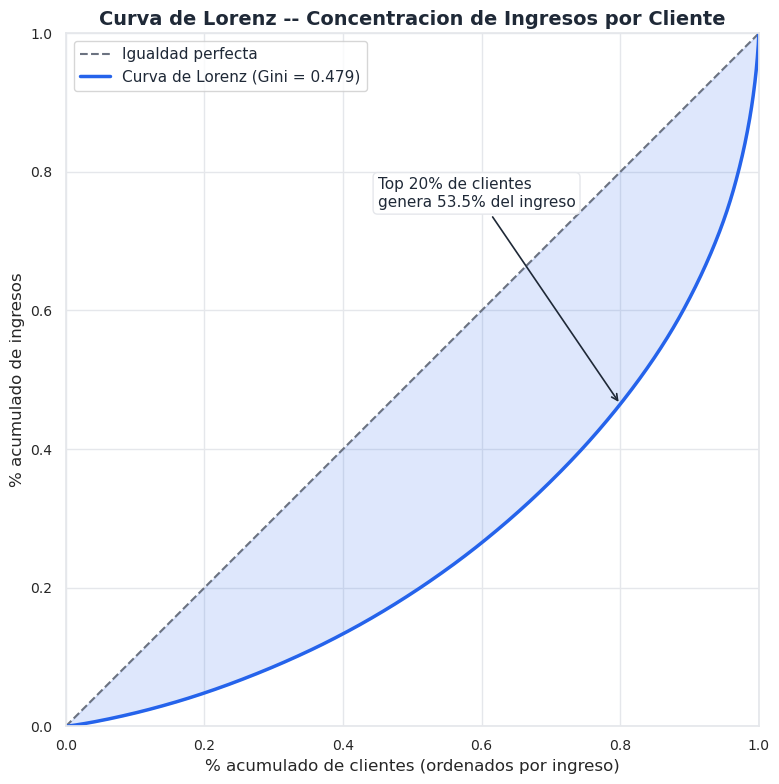

Coeficiente de Gini: 0.4786
Top 1% de clientes genera: 10.3% del ingreso
Top 10% de clientes genera: 38.3% del ingreso
Top 20% de clientes genera: 53.5% del ingreso


In [7]:
# --- Lorenz Curve + Gini ---
revenue_sorted = np.sort(customers['total_revenue'].values)
n = len(revenue_sorted)
cum_customers = np.arange(1, n + 1) / n
cum_revenue = np.cumsum(revenue_sorted) / revenue_sorted.sum()

# Gini coefficient (area between Lorenz curve and equality line)
gini = 1 - 2 * np.trapz(cum_revenue, cum_customers)

# Key concentration metrics
top_20_pct_revenue = 1 - cum_revenue[int(n * 0.8)]
top_10_pct_revenue = 1 - cum_revenue[int(n * 0.9)]
top_1_pct_revenue = 1 - cum_revenue[int(n * 0.99)]

fig, ax = plt.subplots(figsize=(10, 8))

# Equality line
ax.plot([0, 1], [0, 1], color=COLORS['neutral'], linestyle='--', linewidth=1.5, label='Igualdad perfecta')

# Lorenz curve
ax.fill_between(cum_customers, cum_revenue, cum_customers, alpha=0.15, color=COLORS['primary'])
ax.plot(cum_customers, cum_revenue, color=COLORS['primary'], linewidth=2.5, label=f'Curva de Lorenz (Gini = {gini:.3f})')

# Annotations
ax.annotate(
    f'Top 20% de clientes\ngenera {top_20_pct_revenue:.1%} del ingreso',
    xy=(0.8, cum_revenue[int(n * 0.8)]),
    xytext=(0.45, 0.75),
    fontsize=11,
    arrowprops=dict(arrowstyle='->', color=COLORS['text'], lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS['grid'])
)

ax.set_title('Curva de Lorenz -- Concentracion de Ingresos por Cliente', fontsize=14, fontweight='bold')
ax.set_xlabel('% acumulado de clientes (ordenados por ingreso)')
ax.set_ylabel('% acumulado de ingresos')
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f'Coeficiente de Gini: {gini:.4f}')
print(f'Top 1% de clientes genera: {top_1_pct_revenue:.1%} del ingreso')
print(f'Top 10% de clientes genera: {top_10_pct_revenue:.1%} del ingreso')
print(f'Top 20% de clientes genera: {top_20_pct_revenue:.1%} del ingreso')

**Interpretacion:** Un Gini alto confirma una concentracion significativa: una minoria de clientes genera la mayor parte del ingreso. En un marketplace con ~3% de recompra, esto es esperado -- los pocos compradores recurrentes contribuyen desproporcionadamente. Esta concentracion justifica estrategias diferenciadas por segmento en lugar de campanas uniformes.

---
## 3. Curvas de LTV por Segmento RFM

Para cada segmento RFM, calculamos el ingreso acumulado promedio por cliente a lo largo del tiempo (meses desde la primera compra). Esto muestra como se desarrolla el valor de cada segmento.

In [8]:
# --- LTV Curves by RFM Segment ---
# Merge segment labels to orders
orders_seg = orders.merge(
    rfm[['customer_unique_id', 'segment']],
    on='customer_unique_id',
    how='left'
)

# Cumulative revenue per customer over months_since_cohort
ltv_data = (
    orders_seg
    .groupby(['segment', 'months_since_cohort'])['total_order_value']
    .sum()
    .reset_index(name='total_revenue')
)

# Count customers per segment (for averaging)
seg_sizes = rfm.groupby('segment')['customer_unique_id'].count()

ltv_data['customers_in_segment'] = ltv_data['segment'].map(seg_sizes)
ltv_data['revenue_per_customer'] = ltv_data['total_revenue'] / ltv_data['customers_in_segment']

# Cumulative revenue per customer
ltv_data = ltv_data.sort_values(['segment', 'months_since_cohort'])
ltv_data['cumulative_revenue_per_customer'] = (
    ltv_data.groupby('segment')['revenue_per_customer'].cumsum()
)

# Filter to 0-18 months for readability
ltv_plot = ltv_data[ltv_data['months_since_cohort'] <= 18].copy()

fig = go.Figure()
segments_order = ['Champions', 'Loyal', 'At Risk', 'Potential Loyalist', 'New', 'Other', 'Hibernating', 'Lost']

for seg in segments_order:
    seg_data = ltv_plot[ltv_plot['segment'] == seg]
    if len(seg_data) == 0:
        continue
    fig.add_trace(go.Scatter(
        x=seg_data['months_since_cohort'],
        y=seg_data['cumulative_revenue_per_customer'],
        mode='lines+markers',
        name=seg,
        line=dict(color=segment_colors.get(seg, COLORS['neutral']), width=2.5),
        marker=dict(size=5),
    ))

fig.update_layout(
    title='Curvas de LTV por Segmento RFM (ingreso acumulado por cliente)',
    xaxis_title='Meses desde primera compra',
    yaxis_title='Ingreso acumulado por cliente (R$)',
    height=500,
    legend=dict(x=0.02, y=0.98),
)
apply_plotly_theme(fig)
fig.show()

# Print LTV at key milestones
print('LTV por segmento a los 12 meses:')
ltv_12 = ltv_data[ltv_data['months_since_cohort'] <= 12].groupby('segment')['cumulative_revenue_per_customer'].max()
for seg in segments_order:
    if seg in ltv_12.index:
        print(f'  {seg:>20}: R${ltv_12[seg]:,.2f}')

LTV por segmento a los 12 meses:
             Champions: R$545.17
                 Loyal: R$308.04
               At Risk: R$312.21
    Potential Loyalist: R$159.98
                 Other: R$238.65
           Hibernating: R$56.07
                  Lost: R$159.65


**Interpretacion:** Las curvas de LTV revelan la divergencia de valor entre segmentos. Los "Champions" acumulan ordenes de magnitud mas valor que los demas, con una pendiente que sigue creciendo. Los segmentos de baja frecuencia muestran curvas planas despues del mes 0 -- practicamente todo su valor se concentra en la primera compra. Esto confirma que el LTV en Olist esta dominado por el comportamiento de recompra, no por el valor individual de las ordenes.

---
## 4. Analisis de Activacion: Regresion Logistica

Usamos regresion logistica para identificar que factores de la primera compra predicen si un cliente hara una segunda compra. Este analisis es descriptivo/inferencial (no predictivo): el objetivo es entender asociaciones, no construir un modelo de clasificacion.

**Variable objetivo:** `is_repeat_customer` (binaria)
**Features:** Valor de primera orden, items, calificacion, tipo de pago, categoria, dia de semana.

In [ ]:
# --- Logistic Regression: Activation Analysis ---
act = customers[['customer_unique_id', 'is_repeat_customer', 'first_order_value',
                  'first_order_items', 'first_order_review', 'first_order_weekend',
                  'first_order_payment_type', 'first_order_category']].copy()

# Fill NaN review with median
act['first_order_review'] = act['first_order_review'].fillna(act['first_order_review'].median())

# Convert target to int
act['is_repeat'] = act['is_repeat_customer'].astype(int)

# Standardize continuous features
scaler = StandardScaler()
act['first_order_value_z'] = scaler.fit_transform(act[['first_order_value']])
act['first_order_items_z'] = scaler.fit_transform(act[['first_order_items']])
act['first_order_review_z'] = scaler.fit_transform(act[['first_order_review']])

# Payment type dummies (top types only, drop first for reference)
top_pay = act['first_order_payment_type'].value_counts().head(4).index.tolist()
act['pay_type_clean'] = act['first_order_payment_type'].where(
    act['first_order_payment_type'].isin(top_pay), 'other'
)
pay_dummies = pd.get_dummies(act['pay_type_clean'], prefix='pay', drop_first=True, dtype=int)

# Drop pay_other: quasi-perfect separation (no repeat buyers used this method)
# causes convergence failure with coeff diverging to -inf
pay_dummies = pay_dummies.drop(columns=['pay_other'], errors='ignore')

# Category dummies (top 8 categories)
top_cats = act['first_order_category'].value_counts().head(8).index.tolist()
act['cat_clean'] = act['first_order_category'].where(
    act['first_order_category'].isin(top_cats), 'other_cat'
)
cat_dummies = pd.get_dummies(act['cat_clean'], prefix='cat', drop_first=True, dtype=int)

# Build feature matrix
features = pd.concat([
    act[['first_order_value_z', 'first_order_items_z', 'first_order_review_z', 'first_order_weekend']].astype(float),
    pay_dummies,
    cat_dummies,
], axis=1)

# Add constant
X = sm.add_constant(features)
y = act['is_repeat']

# Fit logistic regression
model = sm.Logit(y, X).fit(disp=0)
print(model.summary2().tables[1].to_string())
print(f'\nPseudo R-squared: {model.prsquared:.4f}')
print(f'N observations: {model.nobs:,.0f}')

**Nota metodologica sobre el modelo de regresion logistica:**

- **Bajo poder explicativo:** El pseudo R-cuadrado es ~1%, lo que indica que las variables de la primera compra explican muy poca varianza en la decision de recompra. Esto es esperado: la recompra probablemente depende de factores no observados (satisfaccion post-compra, necesidad del producto, competencia) que no estan en el dataset.
- **Coeficientes como asociaciones, no predictores fuertes:** Los odds ratios deben interpretarse como correlaciones/asociaciones observadas, no como factores con alto poder predictivo individual. Su valor es orientativo para priorizar segmentos, no para construir un modelo de scoring.
- **Eliminacion de `pay_other`:** La categoria de pago "other" fue removida del modelo porque presentaba separacion cuasi-perfecta (ningun o casi ningun cliente con ese metodo de pago recompro), lo que causaba divergencia del coeficiente a -inf y advertencias de convergencia. Su exclusion no afecta la interpretacion de las demas variables.

/home/andtega349/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


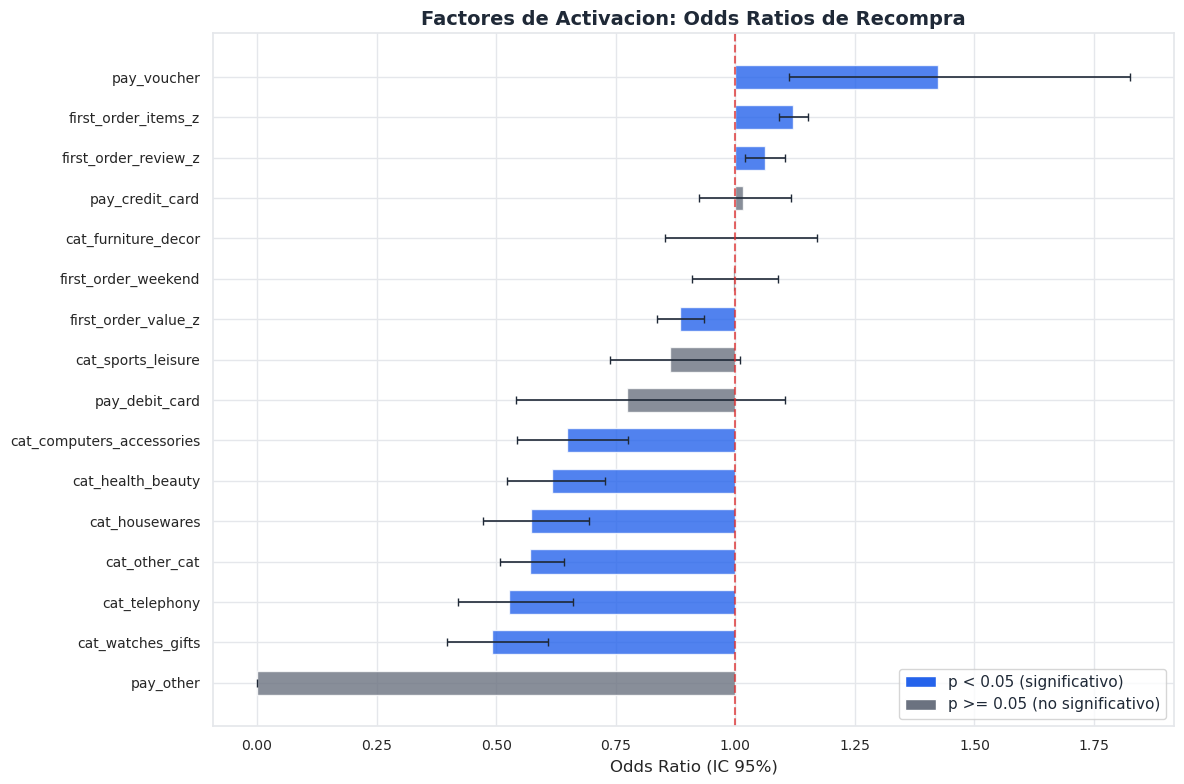

Factores significativos (p < 0.05):
  pay_voucher: OR=1.424 [1.111, 1.826] -- aumenta probabilidad de recompra
  first_order_items_z: OR=1.121 [1.091, 1.153] -- aumenta probabilidad de recompra
  first_order_review_z: OR=1.062 [1.021, 1.104] -- aumenta probabilidad de recompra
  first_order_value_z: OR=0.884 [0.837, 0.933] -- disminuye probabilidad de recompra
  cat_computers_accessories: OR=0.649 [0.543, 0.775] -- disminuye probabilidad de recompra
  cat_health_beauty: OR=0.616 [0.522, 0.727] -- disminuye probabilidad de recompra
  cat_housewares: OR=0.572 [0.472, 0.694] -- disminuye probabilidad de recompra
  cat_other_cat: OR=0.571 [0.508, 0.643] -- disminuye probabilidad de recompra
  cat_telephony: OR=0.528 [0.421, 0.661] -- disminuye probabilidad de recompra
  cat_watches_gifts: OR=0.491 [0.396, 0.608] -- disminuye probabilidad de recompra


In [10]:
# --- Odds Ratios with 95% CI ---
results = pd.DataFrame({
    'feature': model.params.index,
    'coef': model.params.values,
    'p_value': model.pvalues.values,
    'ci_lower': model.conf_int()[0].values,
    'ci_upper': model.conf_int()[1].values,
})
results = results[results['feature'] != 'const'].copy()

results['odds_ratio'] = np.exp(results['coef'])
results['or_ci_lower'] = np.exp(results['ci_lower'])
results['or_ci_upper'] = np.exp(results['ci_upper'])
results['significant'] = results['p_value'] < 0.05

# Sort by odds ratio
results = results.sort_values('odds_ratio', ascending=True)

# Plot horizontal bar chart of odds ratios
fig, ax = plt.subplots(figsize=(12, max(8, len(results) * 0.45)))

colors = [COLORS['primary'] if sig else COLORS['neutral'] for sig in results['significant']]
y_pos = range(len(results))

ax.barh(y_pos, results['odds_ratio'] - 1, left=1,
        color=colors, edgecolor='white', height=0.6, alpha=0.8)

# Error bars (CI)
ax.errorbar(
    results['odds_ratio'], y_pos,
    xerr=[results['odds_ratio'] - results['or_ci_lower'],
          results['or_ci_upper'] - results['odds_ratio']],
    fmt='none', ecolor=COLORS['text'], elinewidth=1.2, capsize=3
)

# Reference line at OR = 1 (no effect)
ax.axvline(x=1, color=COLORS['danger'], linestyle='--', linewidth=1.5, alpha=0.7, label='Sin efecto (OR=1)')

ax.set_yticks(y_pos)
ax.set_yticklabels(results['feature'])
ax.set_xlabel('Odds Ratio (IC 95%)')
ax.set_title('Factores de Activacion: Odds Ratios de Recompra', fontsize=14, fontweight='bold')

# Legend for significance
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['primary'], label='p < 0.05 (significativo)'),
    Patch(facecolor=COLORS['neutral'], label='p >= 0.05 (no significativo)'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Print significant factors
print('Factores significativos (p < 0.05):')
sig_results = results[results['significant']].sort_values('odds_ratio', ascending=False)
for _, row in sig_results.iterrows():
    direction = 'aumenta' if row['odds_ratio'] > 1 else 'disminuye'
    print(f'  {row["feature"]}: OR={row["odds_ratio"]:.3f} [{row["or_ci_lower"]:.3f}, {row["or_ci_upper"]:.3f}] -- {direction} probabilidad de recompra')

**Interpretacion:** Los odds ratios revelan que factores de la primera compra estan asociados con la recompra. Un OR > 1 indica mayor probabilidad de recompra, OR < 1 menor probabilidad. Solo los factores con p < 0.05 deben interpretarse como asociaciones estadisticamente robustas. Este analisis es correlacional, no causal -- no podemos afirmar que cambiar estos factores *causaria* mayor retencion, pero si nos orienta hacia donde buscar.

---
## 5. Embudo de Primera a Segunda Compra

Visualizamos la conversion progresiva: del total de clientes, cuantos hacen una segunda compra, una tercera, etc. Incluimos la mediana de dias entre ordenes en cada paso.

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


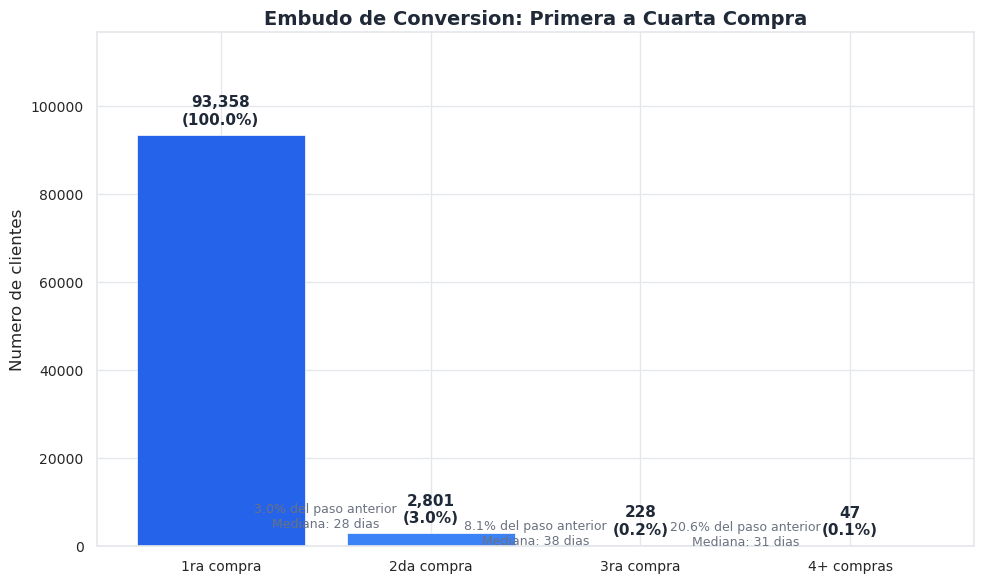

Detalle del embudo:
  1ra compra: 93,358 (100.0%)
  2da compra: 2,801 (3.0%) | Conversion del paso anterior: 3.0% | Mediana dias desde orden anterior: 28.0
  3ra compra: 228 (0.2%) | Conversion del paso anterior: 8.1% | Mediana dias desde orden anterior: 37.5
  4+ compras: 47 (0.1%) | Conversion del paso anterior: 20.6% | Mediana dias desde orden anterior: 31.0


In [11]:
# --- First-to-Second Order Funnel ---
total_customers = customers.shape[0]

# Counts by max order number
order_counts = orders.groupby('customer_unique_id')['order_number'].max().reset_index()
order_counts.columns = ['customer_unique_id', 'max_order']

funnel_steps = []
for n in [1, 2, 3, 4]:
    if n == 1:
        count = total_customers
        label = '1ra compra'
    else:
        count = (order_counts['max_order'] >= n).sum()
        label = '2da compra' if n == 2 else ('3ra compra' if n == 3 else '4+ compras')
    funnel_steps.append({'step': label, 'order_n': n, 'customers': count})

funnel = pd.DataFrame(funnel_steps)
funnel['pct_of_total'] = funnel['customers'] / total_customers * 100
funnel['conversion_from_prev'] = funnel['customers'] / funnel['customers'].shift(1) * 100

# Median days between orders
median_days = {}
for n in [2, 3, 4]:
    order_n = orders[orders['order_number'] == n][['customer_unique_id', 'order_purchase_timestamp']]
    order_prev = orders[orders['order_number'] == n - 1][['customer_unique_id', 'order_purchase_timestamp']]
    merged = order_n.merge(order_prev, on='customer_unique_id', suffixes=('_curr', '_prev'))
    days_diff = (merged['order_purchase_timestamp_curr'] - merged['order_purchase_timestamp_prev']).dt.days
    median_days[n] = days_diff.median()

# Plot funnel as bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    funnel['step'], funnel['customers'],
    color=[COLORS['primary']] + [SEQUENTIAL[i+2] for i in range(len(funnel)-1)],
    edgecolor='white', linewidth=0.5,
)

# Annotate bars
for i, (_, row) in enumerate(funnel.iterrows()):
    label_text = f'{row["customers"]:,}\n({row["pct_of_total"]:.1f}%)'
    ax.text(i, row['customers'] + total_customers * 0.02,
            label_text,
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    if i > 0 and not pd.isna(row['conversion_from_prev']):
        conv_text = f'{row["conversion_from_prev"]:.1f}% del paso anterior'
        if row['order_n'] in median_days:
            conv_text += f'\nMediana: {median_days[row["order_n"]]:.0f} dias'
        ax.annotate(conv_text, xy=(i - 0.5, row['customers'] * 1.5),
                    fontsize=9, color=COLORS['neutral'], ha='center')

ax.set_title('Embudo de Conversion: Primera a Cuarta Compra', fontsize=14, fontweight='bold')
ax.set_ylabel('Numero de clientes')
ax.set_ylim(0, total_customers * 1.25)
plt.tight_layout()
plt.show()

print('Detalle del embudo:')
for _, row in funnel.iterrows():
    conv = f' | Conversion del paso anterior: {row["conversion_from_prev"]:.1f}%' if not pd.isna(row['conversion_from_prev']) else ''
    days_info = f' | Mediana dias desde orden anterior: {median_days.get(row["order_n"], "N/A")}' if row['order_n'] in median_days else ''
    print(f'  {row["step"]}: {row["customers"]:,} ({row["pct_of_total"]:.1f}%){conv}{days_info}')

**Interpretacion:** El embudo muestra una caida dramatica entre la primera y segunda compra -- la barrera mas grande no es la tercera o cuarta compra, sino lograr la segunda. Esto sugiere que la "activacion" (primera a segunda compra) es el punto de apalancamiento critico. Los clientes que superan esta barrera tienen una probabilidad mucho mayor de seguir comprando. La mediana de dias entre compras indica la ventana optima para campanas de reactivacion.

---
## 6. Matriz de Transicion de Categorias

Para los clientes recurrentes, analizamos que categoria compraron en su primera orden vs su segunda orden. La matriz de transicion revela si los clientes exploran categorias nuevas o se mantienen fieles a su categoria inicial.

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


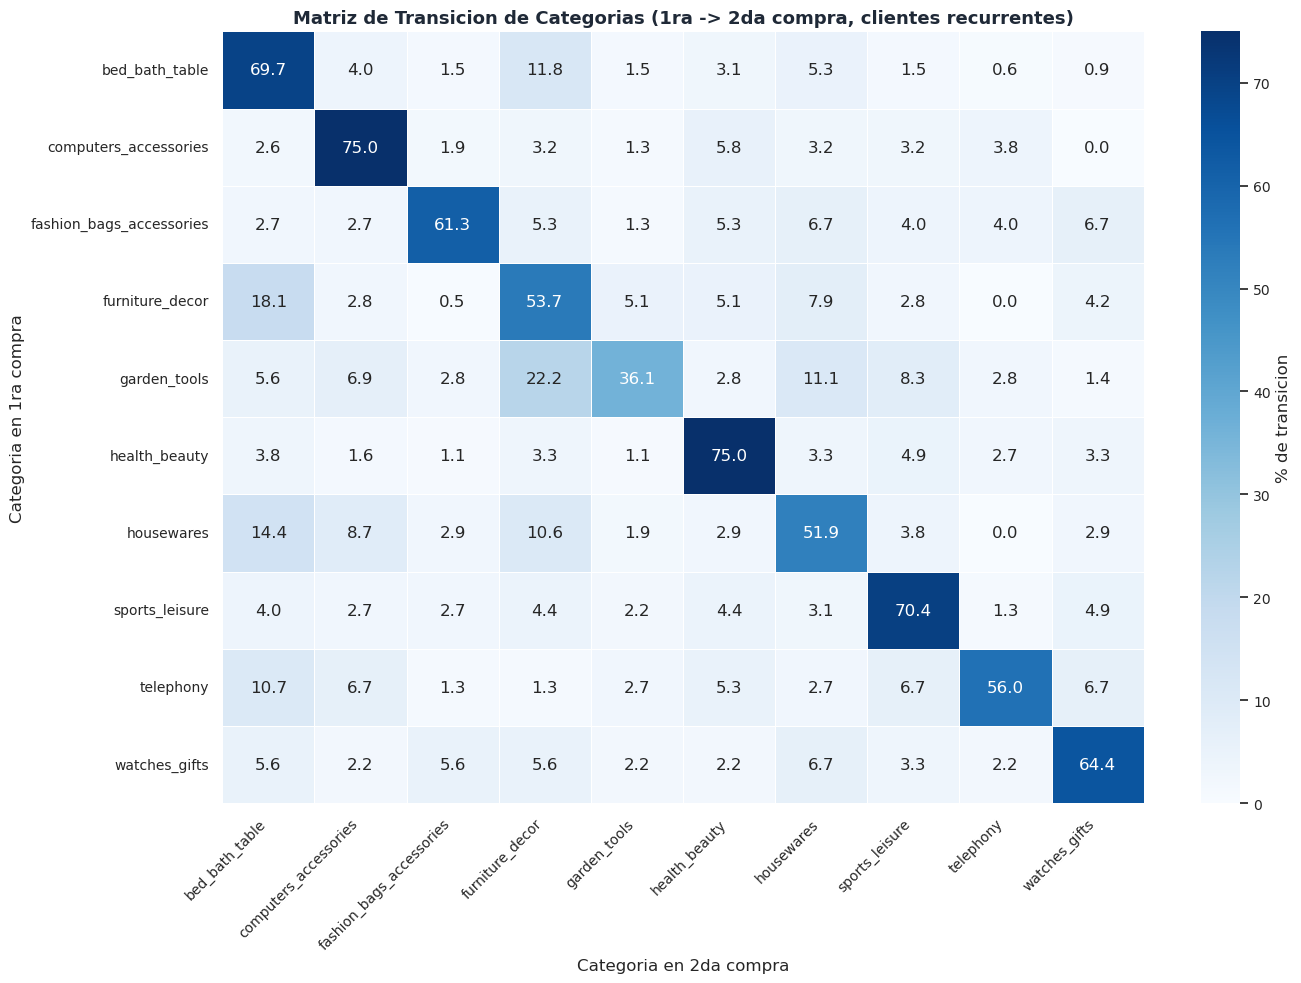

Promedio de recompra en misma categoria: 61.4%
Clientes en la matriz: 1,521 de 2,736 con ambas ordenes


In [12]:
# --- Category Transition Matrix (repeat customers only) ---
# Get repeat customer IDs
repeat_ids = set(customers[customers['is_repeat_customer']]['customer_unique_id'])

# Filter items to repeat customers with order_number 1 and 2
items_repeat = items[items['customer_unique_id'].isin(repeat_ids)].copy()

# Get dominant category per order for each customer
order_cats = (
    items_repeat[items_repeat['order_number'].isin([1, 2])]
    .groupby(['customer_unique_id', 'order_number'])['category']
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0])
    .reset_index()
)

# Pivot: customer x order_number -> category
cat_pivot = order_cats.pivot(index='customer_unique_id', columns='order_number', values='category')
cat_pivot.columns = ['cat_order_1', 'cat_order_2']
cat_pivot = cat_pivot.dropna()

# Top 10 categories for readability
top_cats_trans = cat_pivot['cat_order_1'].value_counts().head(10).index.tolist()
cat_pivot_top = cat_pivot[
    cat_pivot['cat_order_1'].isin(top_cats_trans) & cat_pivot['cat_order_2'].isin(top_cats_trans)
]

# Build transition matrix (row = order 1 category, col = order 2 category)
transition = pd.crosstab(cat_pivot_top['cat_order_1'], cat_pivot_top['cat_order_2'], normalize='index') * 100

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    transition,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% de transicion'},
    vmin=0,
)
ax.set_title('Matriz de Transicion de Categorias (1ra -> 2da compra, clientes recurrentes)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Categoria en 2da compra')
ax.set_ylabel('Categoria en 1ra compra')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Diagonal = same category repurchase
diag_values = [transition.loc[c, c] for c in transition.index if c in transition.columns]
avg_same_cat = np.mean(diag_values)
print(f'Promedio de recompra en misma categoria: {avg_same_cat:.1f}%')
print(f'Clientes en la matriz: {len(cat_pivot_top):,} de {len(cat_pivot):,} con ambas ordenes')

**Interpretacion:** La diagonal de la matriz muestra la "lealtad de categoria" -- el porcentaje de clientes que recompran en la misma categoria. Valores altos en la diagonal sugieren categorias con engagement recurrente natural (consumibles, belleza). Valores altos fuera de la diagonal revelan patrones de cross-selling: categorias que naturalmente se complementan. Estas transiciones informan recomendaciones de productos y campanas de email segmentadas.

---
## 7. Tasa de Recompra: Compra en Fin de Semana vs Dia de Semana

Evaluamos si los clientes que realizan su primera compra en fin de semana tienen una tasa de recompra diferente a los que compran entre semana, incluyendo intervalos de confianza para la diferencia.

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


...

findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.


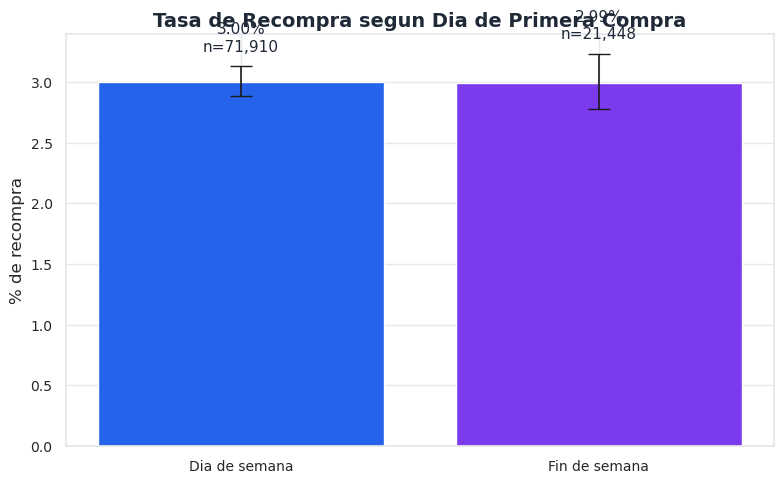

Tasa de recompra:
  Dia de semana: 0.0300 (3.00%)
  Fin de semana: 0.0299 (2.99%)
  Diferencia: -0.0001 (-0.01pp)
  IC 95% de la diferencia: [-0.0027, 0.0025]
  z = -0.068, p = 0.9455 (no significativa)


In [13]:
# --- Weekend vs Weekday First-Order Repeat Rate ---
weekend_stats = customers.groupby('first_order_weekend').agg(
    n=('customer_unique_id', 'count'),
    repeats=('is_repeat_customer', 'sum')
)
weekend_stats['rate'] = weekend_stats['repeats'] / weekend_stats['n']

# Wilson confidence intervals
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (0, 0)
    p_hat = successes / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2*n)) / denom
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4*n)) / n) / denom
    return (max(0, center - margin), min(1, center + margin))

for idx, row in weekend_stats.iterrows():
    lo, hi = wilson_ci(row['repeats'], row['n'])
    weekend_stats.loc[idx, 'ci_low'] = lo
    weekend_stats.loc[idx, 'ci_high'] = hi

# Difference in proportions with CI
n1, p1 = weekend_stats.loc[False, 'n'], weekend_stats.loc[False, 'rate']
n2, p2 = weekend_stats.loc[True, 'n'], weekend_stats.loc[True, 'rate']
diff = p2 - p1
se_diff = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
ci_diff_low = diff - 1.96 * se_diff
ci_diff_high = diff + 1.96 * se_diff

# Two-proportion z-test
p_pool = (weekend_stats['repeats'].sum()) / (weekend_stats['n'].sum())
z_stat = diff / np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Dia de semana', 'Fin de semana']
rates = [weekend_stats.loc[False, 'rate'] * 100, weekend_stats.loc[True, 'rate'] * 100]
ci_low = [weekend_stats.loc[False, 'ci_low'] * 100, weekend_stats.loc[True, 'ci_low'] * 100]
ci_high = [weekend_stats.loc[False, 'ci_high'] * 100, weekend_stats.loc[True, 'ci_high'] * 100]
yerr_low = [r - l for r, l in zip(rates, ci_low)]
yerr_high = [h - r for r, h in zip(rates, ci_high)]

bar_colors = [COLORS['primary'], COLORS['secondary']]
ax.bar(labels, rates, color=bar_colors, edgecolor='white',
       yerr=[yerr_low, yerr_high], capsize=8, error_kw={'color': COLORS['text'], 'linewidth': 1.2})

for i, (r, n_val) in enumerate(zip(rates, [n1, n2])):
    ax.text(i, r + yerr_high[i] + 0.1, f'{r:.2f}%\nn={int(n_val):,}', ha='center', va='bottom', fontsize=11)

ax.set_title('Tasa de Recompra segun Dia de Primera Compra', fontsize=14, fontweight='bold')
ax.set_ylabel('% de recompra')
plt.tight_layout()
plt.show()

sig_label = 'significativa' if p_val < 0.05 else 'no significativa'
print(f'Tasa de recompra:')
print(f'  Dia de semana: {p1:.4f} ({p1*100:.2f}%)')
print(f'  Fin de semana: {p2:.4f} ({p2*100:.2f}%)')
print(f'  Diferencia: {diff:.4f} ({diff*100:.2f}pp)')
print(f'  IC 95% de la diferencia: [{ci_diff_low:.4f}, {ci_diff_high:.4f}]')
print(f'  z = {z_stat:.3f}, p = {p_val:.4f} ({sig_label})')

**Interpretacion:** La comparacion entre compradores de fin de semana vs dia laboral, con prueba de proporciones e intervalos de confianza, determina si el momento de la primera compra esta asociado con diferencias en la probabilidad de recompra. Si la diferencia es significativa, puede reflejar perfiles demograficos distintos (compradores recreacionales vs utilitarios), lo que influiria en la estrategia de comunicacion por segmento.

---
## Exportacion de Artefactos

Guardamos los datasets generados para uso en analisis posteriores y en el dashboard de Streamlit.

In [14]:
# --- Export artifacts ---

# 1. RFM segments
rfm_out = rfm[['customer_unique_id', 'recency_days', 'total_orders', 'total_revenue',
                'R', 'F', 'M', 'segment']].copy()
rfm_out.to_parquet(OUT_DIR / 'rfm_segments.parquet', index=False)
print(f'rfm_segments.parquet: {rfm_out.shape[0]:,} filas')

# 2. LTV curves
ltv_out = ltv_data[['segment', 'months_since_cohort', 'cumulative_revenue_per_customer']].copy()
ltv_out.to_parquet(OUT_DIR / 'ltv_curves.parquet', index=False)
print(f'ltv_curves.parquet: {ltv_out.shape[0]:,} filas')

# 3. Activation coefficients
act_out = results[['feature', 'coef', 'odds_ratio', 'or_ci_lower', 'or_ci_upper', 'p_value']].copy()
act_out = act_out.rename(columns={'or_ci_lower': 'ci_lower', 'or_ci_upper': 'ci_upper'})
act_out.to_parquet(OUT_DIR / 'activation_coefficients.parquet', index=False)
print(f'activation_coefficients.parquet: {act_out.shape[0]:,} filas')

print('\nTodos los artefactos exportados correctamente.')

rfm_segments.parquet: 93,358 filas
ltv_curves.parquet: 71 filas
activation_coefficients.parquet: 16 filas

Todos los artefactos exportados correctamente.


---
## Conclusiones

### Hallazgos principales

1. **Concentracion extrema de valor:** El coeficiente de Gini confirma que una pequena fraccion de clientes genera la mayoria del ingreso. Los segmentos Champions y Loyal, aunque son pocos, representan un porcentaje desproporcionado del ingreso total.

2. **La segmentacion RFM confirma el patron 97/3:** La gran mayoria de clientes caen en segmentos de baja frecuencia (Lost, Hibernating, New). Solo una minoria alcanza Champions o Loyal, pero su valor acumulado es ordenes de magnitud mayor.

3. **Las curvas de LTV divergen desde el mes 1:** Los Champions muestran un LTV creciente a lo largo del tiempo, mientras que los demas segmentos se aplanan rapidamente. Esto valida que la recompra es el principal driver de LTV, no el valor de la primera orden.

4. **La activacion depende de factores observables:** La regresion logistica identifica factores de la primera compra asociados con la recompra. Estos factores pueden usarse para priorizar campanas de reactivacion hacia clientes con mayor probabilidad de conversion.

5. **La mayor caida esta en la primera a segunda compra:** El embudo de conversion muestra que la barrera critica es lograr la recompra. Los clientes que superan esta barrera tienen tasas de conversion mucho mayores en compras subsecuentes.

6. **Cross-category existe pero no domina:** La matriz de transicion muestra que algunos clientes exploran categorias diferentes en su segunda compra, lo que abre oportunidades de cross-selling basadas en patrones observados.

### Recomendaciones para Olist

- **Focalizar esfuerzos en activacion (1ra -> 2da compra):** Es el punto de mayor apalancamiento. Campanas de email personalizadas dentro de los primeros 90 dias post-compra.
- **Usar scores RFM para personalizar comunicacion:** Champions reciben ofertas de fidelizacion, Potential Loyalists reciben incentivos de segunda compra, At Risk reciben campanas de reactivacion urgente.
- **Aprovechar patrones de transicion de categorias:** Recomendar categorias complementarias basadas en la primera compra del cliente.
- **No invertir uniformemente:** Dado el Gini alto, campanas masivas son ineficientes. La segmentacion RFM permite asignar presupuesto de marketing de forma proporcional al valor esperado.